# Timoshenko Beam Analysis - Ritz

## Definição do problema e variáveis simbólicas

Nesta etapa, são importadas as bibliotecas necessárias para manipulação simbólica e visualização dos resultados.

A biblioteca `sympy` é utilizada para realizar operações analíticas, enquanto `numpy` e `matplotlib` são empregadas para avaliação numérica e geração de gráficos.

Em seguida, são definidas as variáveis simbólicas do problema:

- \( x \): coordenada ao longo da viga
- \( y \): coordenada transversal (altura da seção)   
- \( E \): módulo de elasticidade
- \( G \): módulo de cisalhamento transversal
- \( I \): momento de inércia da seção  
- \( A \): área da seção transversal  
- \( L \): comprimento da viga  
- \( q_0 \): carga distribuída  
- \( s_0 \): parâmetro auxiliar (por exemplo, força ou condição de contorno)

Diferentemente da viga de Bernoulli, a viga de Timoshenko possui duas incógnitas independentes:

- $ \nu(x) $: deslocamento transversal  
- $ \phi(x) $: rotação da seção transversal 

In [84]:
# Importar todos os comandos da biblioteca sympy
from sympy import *
from sympy import lambdify
from scipy.integrate import quad
import matplotlib.pyplot as plt
import numpy as np
# Para uma impressão mais elegante:
init_printing(use_unicode=True)
# Declarar variáveis simbólicas
E, G, A, I, L, q0, s0, k = symbols('E G A I L q0 s0 k')
### "k" --> fator de correção de cisalhamento (≈ 5/6 para seção retangular)
a11,a21,a22,a31,a32,a33,a41,a42,a43,a44,a51,a52,a53,a54,a55 = symbols('a11 a21 a22 a31 a32 a33 a41 a42 a43 a44 a51 a52 a53 a54 a55')
b11,b21,b22,b31,b32,b33,b41,b42,b43,b44,b51,b52,b53,b54,b55 = symbols('b11 b21 b22 b31 b32 b33 b41 b42 b43 b44 b51 b52 b53 b54 b55')

# Variáveis simbólicas
x = symbols('x')
y = symbols('y')
C1, C2, C3, C4, C5, C6, C7 = symbols('C1 C2 C3 C4 C5 C6 C7')

# Funções incógnitas (Timoshenko!)
v = symbols('v', cls=Function)
phi = symbols('phi', cls=Function)

## 🔹 Solução analítica do problema (Viga de Timoshenko)

Nesta etapa, resolve-se o problema de equilíbrio de uma viga considerando deformações de flexão e cisalhamento.

O problema é descrito por um sistema de equações diferenciais acopladas:

$$
\frac{d}{dx}\left[k G A \left(\phi + \frac{dv}{dx}\right)\right] + q(x) = 0
$$

$$
E I \frac{d^2 \phi}{dx^2} - k G A \left(\phi + \frac{dv}{dx}\right) = 0
$$


onde:
- $ k $ é o fator de correção de cisalhamento  
- $ q(x) = (q_0/x) $ é o carregamento distribuído

---

🔹 Equação diferencial desacoplada

Eliminando v(x) para obter $\phi(x)$, obtém-se:

$$
E I \frac{d^3 \phi}{dx^3} + q(x) = 0
$$

Esta equação governa rotacao transversal da viga.

---

🔹 Condições de contorno (viga biapoiada)

Rotacao nula no meio da viga:
$$
\phi(L/2) = 0
$$
$$
\frac{d\phi}{dx}(L/2) = 0
$$

Momento fletor nulo (apoios livres para rotação): 
$$ 
M(0) = E I \frac{d\phi}{dx}(0) = 0
$$ 
$$ 
M(L) = E I \frac{d\phi}{dx}(L) = 0 
$$

---

🔹 Campos de deformação

As deformações são dadas por:

- Curvatura (flexão):
$$
\kappa(x) = \frac{d\phi}{dx}
$$

- Deformação de cisalhamento:
$$
\gamma_{xy}(x) = \phi(x) + \frac{dv}{dx}
$$

---

🔹 Campos de tensão

- Tensão normal (flexão):
$$
\sigma_x(x,y) = E y \frac{d\phi}{dx}
$$

- Tensão de cisalhamento:
$$
\tau_{xy}(x) = k G \left(\phi + \frac{dv}{dx}\right)
$$

---

🔹 Energia potencial total

A energia potencial total do sistema é dada por:

$$
\Pi = \int_0^L \left[
\frac{E I}{2} \left(\frac{d\phi}{dx}\right)^2
+ \frac{k G A}{2} \left(\phi + \frac{dv}{dx}\right)^2
- q(x)\,v
\right] dx
$$

In [85]:
# Solução analítica do problema: equações de Timoshenko

# Equação 1 (equilíbrio transversal)
eq1 = Eq((k*G*A*(v(x).diff(x) + phi(x))).diff(x) + q0, 0)

# Equação 2 (momento)
eq2 = Eq(E*I*phi(x).diff(x,2) - k*G*A*(v(x).diff(x) + phi(x)), 0)

# Equação 3 (desacoplada)
eq3 = Eq(E*I*phi(x).diff(x,3) + q0, 0)
print('eq3 =', eq3)
print('')

# A equação diferencial é resolvida simbolicamente, resultando em uma expressão para v(x)
## dsolve(...) Resolve simbolicamente a EDO e retorna algo do tipo 𝑢(𝑥)=expressao com constantes 𝐶1,𝐶2
## ics={...} impõe as condições de contorno
g = dsolve(eq3, phi(x))
f = g.rhs   ###Pega o lado direito de g(x) 

eqs_phi = [
    f.subs(x, L/2),            # simetria: phi(L/2)=0
    diff(f, x).subs(x, 0),     # M(0)=0 → phi'(0)=0
    diff(f, x).subs(x, L)      # M(L)=0 → phi'(L)=0
]
consts_phi = solve(eqs_phi, [C1, C2, C3])
f = f.subs(consts_phi)

# Equação 4 (rearranjo para recuperar v(x))
v_prime = (E*I)/(k*G*A)*diff(f, x, 2) - f

h_solve = dsolve(Eq(diff(v(x), x), v_prime), v(x))
h = h_solve.rhs   ###Pega o lado direito de h_solve(x) 
# Condições de contorno em v (biapoiada)
eqs_v = [
    h.subs(x, 0),        # v(0)=0 
    h.subs(x, L)         # v(L)=0 
]
consts_v = solve(eqs_v, dict=True)[0]
h = h.subs(consts_v)

print('phi(x) =',f)
print('')
print('v(x) =', h)
print('')

# Deformação de cisalhamento
gamma = f + h.diff(x)
# Tensão normal (flexão)
sigma = E*y*f.diff(x)
print('sigma_x(x,y) =', sigma)
print('')
# Tensão de cisalhamento
tau = k*G*gamma
print('tau_xy(x) =', tau)

# Funcional de energia potencial
Pi = integrate(
    (E*I*(f.diff(x))**2)/2
    + (k*G*A*(f + h.diff(x))**2)/2
    - q0*h,
    (x,0,L)
)
#print('Pi =', Pi)
print('')
print('Pi = ', N(Pi.subs([(E, 200e9), (A, 50e-6), (G,77e9), (I,1e-6), (k,5/6), (q0, 10), (L, 4)]),5), '[J]')

eq3 = Eq(E*I*Derivative(phi(x), (x, 3)) + q0, 0)

phi(x) = -L**3*q0/(24*E*I) + L*q0*x**2/(4*E*I) - q0*x**3/(6*E*I)

v(x) = L**3*q0*x/(24*E*I) - L*q0*x**3/(12*E*I) + q0*x**4/(24*E*I) + L*q0*x/(2*A*G*k) - q0*x**2/(2*A*G*k)

sigma_x(x,y) = E*y*(L*q0*x/(2*E*I) - q0*x**2/(2*E*I))

tau_xy(x) = G*k*(L*q0/(2*A*G*k) - q0*x/(A*G*k))

Pi =  -0.0022165 [J]


# 🔹 Funções de aproximação Timoshenko
As funções de aproximação para o modelo de Timoshenko se comportam muito bem utilizando a base 4, onde se usa um grau a menos para o polinômio que representa a deformação cisalhante ($\gamma$). Abaixo foi utilizado a base 5, onde tanto $\phi$ como $\gamma$ sao interpolados com a mesma ordem.


---
# Aproximação de ordem 1
$$
v_1(x) = a_{11}\,x(L-x)
$$

$$
\gamma_1(x) = b_{11}\,x(L-x)
$$

$$
\phi_1(x) = \gamma_1(x) - \frac{dv_1}{dx}
$$

---
# Aproximação de ordem 2
$$
v_2(x) = a_{21}\,x(L-x) + a_{22}\,x^2(L-x)
$$

$$
\gamma_2(x) = b_{21}\,x(L-x) + b_{22}\,x^2(L-x)
$$

$$
\phi_2(x) = \gamma_2(x) - \frac{dv_2}{dx}
$$

---
# Aproximação de ordem 3
$$
v_3(x) = a_{31}\,x(L-x) + a_{32}\,x^2(L-x) + a_{33}\,x^3(L-x)
$$

$$
\gamma_3(x) = b_{31}\,x(L-x) + b_{32}\,x^2(L-x) + b_{33}\,x^3(L-x)
$$

$$
\phi_3(x) = \gamma_3(x) - \frac{dv_3}{dx}
$$

---
# Aproximação de ordem 4
$$
v_4(x) = a_{41}\,x(L-x) + a_{42}\,x^2(L-x) + a_{43}\,x^3(L-x) + a_{44}\,x^4(L-x)
$$

$$
\gamma_4(x) = b_{41}\,x(L-x) + b_{42}\,x^2(L-x) + b_{43}\,x^3(L-x) + b_{44}\,x^4(L-x)
$$

$$
\phi_4(x) = \gamma_4(x) - \frac{dv_4}{dx}
$$

---

À medida que o grau do polinômio aumenta, espera-se que a solução aproximada se aproxime da solução exata. Contudo, quando testou-se a ordem 5, não obtêve-se sucesso em convergência.

In [86]:
# Funções de aproximação Timoshenko
# Ordem 1
v1 = a11*x*(L - x)
gamma1 = b11*x*(L - x)
phi1 = gamma1 - diff(v1, x)

# Ordem 2
v2 = a21*x*(L - x) + a22*x**2*(L - x)
gamma2 = b21*x*(L - x) + b22*x**2*(L - x)
phi2 = gamma2 - diff(v2, x)

# Ordem 3
v3 = a31*x*(L - x) + a32*x**2*(L - x) + a33*x**3*(L - x)
gamma3 = b31*x*(L - x) + b32*x**2*(L - x) + b33*x**3*(L - x)
phi3 = gamma3 - diff(v3, x)

# Ordem 4
v4 = a41*x*(L - x) + a42*x**2*(L - x) + a43*x**3*(L - x) + a44*x**4*(L - x)
gamma4 = b41*x*(L - x) + b42*x**2*(L - x) + b43*x**3*(L - x) + b44*x**4*(L - x)
phi4 = gamma4 - diff(v4, x)

# Ordem 5
# v5 = a51*x*(L - x) + a52*x**2*(L - x) + a53*x**3*(L - x) + a54*x**4*(L - x) + a55*x**5*(L - x)
# gamma5 = b51*x*(L - x) + b52*x**2*(L - x) + b53*x**3*(L - x) + b54*x**4*(L - x) + b55*x**5*(L - x)
# phi5 = gamma5 - diff(v5, x)


## Funcional de energia potencial aproximado

### 🔹 Funcional de energia potencial (Timoshenko)
$$
\Pi = \int_0^L \left(
\frac{EI}{2}\,\phi'^2
+ \frac{kGA}{2}\,(\phi + v')^2
- q(x)\,v
\right) dx
$$

### 🔹 Conclusão

O problema contínuo é transformado em um problema discreto:

$$
\Pi_n = \Pi_n(c_1, c_2, \dots)
$$

cuja minimização fornece a solução aproximada.

In [87]:
# Funcional de energia potencial
Pi1 = integrate(
    (E*I*(phi1.diff(x))**2)/2
    + (k*G*A*(phi1 + v1.diff(x))**2)/2
    - q0*v1,
    (x,0,L)
)
print('Pi1 =', Pi1)
print('')
Pi2 = integrate(
    (E*I*(phi2.diff(x))**2)/2
    + (k*G*A*(phi2 + v2.diff(x))**2)/2
    - q0*v2,
    (x,0,L)
)
print('Pi2 =', Pi2)
print('')
Pi3 = integrate(
    (E*I*(phi3.diff(x))**2)/2
    + (k*G*A*(phi3 + v3.diff(x))**2)/2
    - q0*v3,
    (x,0,L)
)
print('Pi3 =', Pi3)
print('')
Pi4 = integrate(
    (E*I*(phi4.diff(x))**2)/2
    + (k*G*A*(phi4 + v4.diff(x))**2)/2
    - q0*v4,
    (x,0,L)
)
print('Pi4 =', Pi4)

Pi5_existe = True
try:
    Pi5 = 0
    print('')
    Pi5 = integrate(
        (E*I*(phi5.diff(x))**2)/2
        + (k*G*A*(phi5 - v5.diff(x))**2)/2
        - q0*v5,
        (x,0,L)
    )
    print('Pi5 =', Pi5)
    print('')
except NameError:
    Pi5_existe = False

Pi1 = -L**3*a11*q0/6 + L*(A*G*b11**2*k/2 + 2*E*I*a11**2)

Pi2 = L**4*a22*q0/4 + L**3*(A*G*b22**2*k/6 + 6*E*I*a22**2 - L*a22*q0/3 + a21*q0/3) + L**2*(A*G*b21*b22*k/2 - 6*E*I*L*a22**2 + 6*E*I*a21*a22 + 3*E*I*a22*b22 - L*a21*q0/2) + L*(A*G*b21**2*k/2 + 2*E*I*L**2*a22**2 - 4*E*I*L*a21*a22 - 2*E*I*L*a22*b22 + 2*E*I*a21**2 + 2*E*I*a21*b22 + E*I*b22**2/2)

Pi3 = A*G*L**7*b33**2*k/14 + L**5*(A*G*b32*b33*k/5 + 72*E*I*a33**2/5 + 36*E*I*a33*b33/5 + 9*E*I*b33**2/10 + a33*q0/5) + L**4*(A*G*b31*b33*k/4 - 18*E*I*L*a33**2 - 9*E*I*L*a33*b33/2 + 18*E*I*a32*a33 + 9*E*I*a32*b33/2 - L*a33*q0/4 + a32*q0/4) + L**3*(A*G*b32**2*k/6 + 6*E*I*L**2*a33**2 - 20*E*I*L*a32*a33 - 2*E*I*L*a32*b33 + 8*E*I*a31*a33 + 2*E*I*a31*b33 + 6*E*I*a32**2 + 4*E*I*a33*b32 + E*I*b32*b33 - L*a32*q0/3 + a31*q0/3) + L**2*(A*G*b31*b32*k/2 + 6*E*I*L**2*a32*a33 - 6*E*I*L*a31*a33 - 6*E*I*L*a32**2 - 3*E*I*L*a33*b32 + 6*E*I*a31*a32 + 3*E*I*a32*b32 - L*a31*q0/2) + L*(A*G*b31**2*k/2 + 2*E*I*L**2*a32**2 - 4*E*I*L*a31*a32 - 2*E*I*L*a32*b32 + 2*E*

## Minimização do funcional de energia (Condições de estacionariedade do funcional)

Nesta etapa, determina-se a solução aproximada impondo a condição de mínimo da energia potencial total (equilíbrio do sistema).Isso é feito derivando o funcional em relação a cada coeficiente e igualando a zero:

Para cada ordem, impõe-se:

$$
\frac{\partial \Pi}{\partial a_{ij}} = 0
\quad \text{e} \quad
\frac{\partial \Pi}{\partial b_{ij}} = 0
$$
---

### 🔹 Conclusão

O problema contínuo foi transformado em um sistema algébrico, cuja solução fornece uma aproximação para o deslocamento:

$$
u(x) \approx u_b(x)
$$

In [88]:
# Ordem 1
dPi1_a1 = Eq(Pi1.diff(a11), 0)
dPi1_b1 = Eq(Pi1.diff(b11), 0)

# Ordem 2
dPi2_a1 = Eq(Pi2.diff(a21), 0)
dPi2_a2 = Eq(Pi2.diff(a22), 0)

dPi2_b1 = Eq(Pi2.diff(b21), 0)
dPi2_b2 = Eq(Pi2.diff(b22), 0)

# Ordem 3
dPi3_a1 = Eq(Pi3.diff(a31), 0)
dPi3_a2 = Eq(Pi3.diff(a32), 0)
dPi3_a3 = Eq(Pi3.diff(a33), 0)

dPi3_b1 = Eq(Pi3.diff(b31), 0)
dPi3_b2 = Eq(Pi3.diff(b32), 0)
dPi3_b3 = Eq(Pi3.diff(b33), 0)

# Ordem 4
dPi4_a1 = Eq(Pi4.diff(a41), 0)
dPi4_a2 = Eq(Pi4.diff(a42), 0)
dPi4_a3 = Eq(Pi4.diff(a43), 0)
dPi4_a4 = Eq(Pi4.diff(a44), 0)

dPi4_b1 = Eq(Pi4.diff(b41), 0)
dPi4_b2 = Eq(Pi4.diff(b42), 0)
dPi4_b3 = Eq(Pi4.diff(b43), 0)
dPi4_b4 = Eq(Pi4.diff(b44), 0)

if Pi5_existe == True:
    # Ordem 5
    dPi5_a1 = Eq(Pi5.diff(a51), 0)
    dPi5_a2 = Eq(Pi5.diff(a52), 0)
    dPi5_a3 = Eq(Pi5.diff(a53), 0)
    dPi5_a4 = Eq(Pi5.diff(a54), 0)
    dPi5_a5 = Eq(Pi5.diff(a55), 0)
    
    dPi5_b1 = Eq(Pi5.diff(b51), 0)
    dPi5_b2 = Eq(Pi5.diff(b52), 0)
    dPi5_b3 = Eq(Pi5.diff(b53), 0)
    dPi5_b4 = Eq(Pi5.diff(b54), 0)
    dPi5_b5 = Eq(Pi5.diff(b55), 0)
    


### 🔹 Sistema de equações

Para cada ordem, resolve-se o sistema:

$$
\frac{\partial \Pi}{\partial a_{ij}} = 0,
\quad
\frac{\partial \Pi}{\partial b_{ij}} = 0
$$

Obtendo os coeficientes da aproximação:
$$
\{a_{ij}, b_{ij}\}
$$


In [89]:
# Ordem 1
sist1 = solve(
    [dPi1_a1, dPi1_b1],
    [a11, b11]
)
print('')
print('a11 =', sist1[a11])
print('b11 =', sist1[b11])
print('')

# Ordem 2
sist2 = solve(
    [dPi2_a1, dPi2_a2, dPi2_b1, dPi2_b2],
    [a21, a22, b21, b22]
)
print('a21 =', sist2[a21])
print('a22 =', sist2[a22])
print('b21 =', sist2[b21])
print('b22 =', sist2[b22])
print('')

# Ordem 3
sist3 = solve(
    [dPi3_a1, dPi3_a2, dPi3_a3,
     dPi3_b1, dPi3_b2, dPi3_b3],
    [a31, a32, a33, b31, b32, b33]
)
print('a31 =', sist3[a31])
print('a32 =', sist3[a32])
print('a33 =', sist3[a33])
print('b31 =', sist3[b31])
print('b32 =', sist3[b32])
print('b33 =', sist3[b33])
print('')

# Ordem 4
sist4 = solve(
    [dPi4_a1, dPi4_a2, dPi4_a3, dPi4_a4,
     dPi4_b1, dPi4_b2, dPi4_b3, dPi4_b4],
    [a41, a42, a43, a44, b41, b42, b43, b44]
)
print('a41 =', sist4[a41])
print('a42 =', sist4[a42])
print('a43 =', sist4[a43])
print('a44 =', sist4[a44])
print('b41 =', sist4[b41])
print('b42 =', sist4[b42])
print('b43 =', sist4[b43])
print('b44 =', sist4[b44])
print('')

if Pi5_existe == True:
    # Ordem 5
    sist5 = solve(
        [dPi5_a1, dPi5_a2, dPi5_a3, dPi5_a4, dPi5_a5,
         dPi5_b1, dPi5_b2, dPi5_b3, dPi5_b4, dPi5_b5],
        [a51, a52, a53, a54, a55, b51, b52, b53, b54, b55]
    )
    print('a51 =', sist5[a51])
    print('a52 =', sist5[a52])
    print('a53 =', sist5[a53])
    print('a54 =', sist5[a54])
    print('a55 =', sist5[a55])
    print('b51 =', sist5[b51])
    print('b52 =', sist5[b52])
    print('b53 =', sist5[b53])
    print('b54 =', sist5[b54])
    print('b55 =', sist5[b55])
    print('')


a11 = L**2*q0/(24*E*I)
b11 = 0

a21 = (A*G*L**2*k*q0 + 12*E*I*q0)/(24*A*E*G*I*k)
a22 = 0
b21 = L*q0/(2*A*G*k)
b22 = -q0/(A*G*k)

a31 = (A*G*L**2*k*q0 + 12*E*I*q0)/(24*A*E*G*I*k)
a32 = L*q0/(24*E*I)
a33 = -q0/(24*E*I)
b31 = L*q0/(2*A*G*k)
b32 = -q0/(A*G*k)
b33 = 0

a41 = (A*G*L**2*k*q0 + 12*E*I*q0)/(24*A*E*G*I*k)
a42 = L*q0/(24*E*I)
a43 = -q0/(24*E*I)
a44 = 0
b41 = L*q0/(2*A*G*k)
b42 = -q0/(A*G*k)
b43 = 0
b44 = 0



### 🔹 Funções aproximadas finais

Após resolver o sistema, substituímos os coeficientes:

$$
v_n(x) = v_n(x, a_{ij})
\quad \Rightarrow \quad v_n(x, a_{ij}^*)
$$

$$
\phi_n(x) = \phi_n(x, b_{ij})
\quad \Rightarrow \quad \phi_n(x, b_{ij}^*)
$$

In [90]:
print('')
# Ordem 1
subs_all1 = {
    a11: sist1[a11],
    b11: sist1[b11],
}
v1s = v1.subs(subs_all1)
phi1s = phi1.subs(subs_all1)
print('v1 =', v1s)
print('')
print('phi1 =', phi1s)
print('')
print('')
print('')
# Ordem 2
subs_all2 = {
    a21: sist2[a21],
    a22: sist2[a22],
    b21: sist2[b21],
    b22: sist2[b22],
}
v2s = v2.subs(subs_all2)
phi2s = phi2.subs(subs_all2)
print('v2 =', v2s)
print('')
print('phi2 =', phi2s)
print('')
print('')
print('')

# Ordem 3
subs_all3 = {
    a31: sist3[a31],
    a32: sist3[a32],
    a33: sist3[a33],
    b31: sist3[b31],
    b32: sist3[b32],
    b33: sist3[b33],
}
v3s = v3.subs(subs_all3)
phi3s = phi3.subs(subs_all3)
print('v3 =', v3s)
print('')
print('phi3 =', phi3s)
print('')
print('')
print('')

# Ordem 4
subs_all4 = {
    a41: sist4[a41],
    a42: sist4[a42],
    a43: sist4[a43],
    a44: sist4[a44],
    b41: sist4[b41],
    b42: sist4[b42],
    b43: sist4[b43],
    b44: sist4[b44],
}

v4s = v4.subs(subs_all4)
phi4s = phi4.subs(subs_all4)
print('v4 =', v4s)
print('')
print('phi4 =', phi4s)
print('')
print('')
print('')

if Pi5_existe == True:
    # Ordem 5
    subs_all5 = {
        a51: sist5[a51],
        a52: sist5[a52],
        a53: sist5[a53],
        a54: sist5[a54],
        a55: sist5[a55],
        b51: sist5[b51],
        b52: sist5[b52],
        b53: sist5[b53],
        b54: sist5[b54],
        b55: sist5[b55],
    }
    
    v5s = v5.subs(subs_all5)
    phi5s = phi5.subs(subs_all5)
    print('v5 =', v5s)
    print('')
    print('phi5 =', phi5s)
    print('')
    print('')


v1 = L**2*q0*x*(L - x)/(24*E*I)

phi1 = L**2*q0*x/(24*E*I) - L**2*q0*(L - x)/(24*E*I)



v2 = x*(L - x)*(A*G*L**2*k*q0 + 12*E*I*q0)/(24*A*E*G*I*k)

phi2 = L*q0/(2*A*G*k) - q0*x/(A*G*k) + x*(A*G*L**2*k*q0 + 12*E*I*q0)/(24*A*E*G*I*k) - (L - x)*(A*G*L**2*k*q0 + 12*E*I*q0)/(24*A*E*G*I*k)



v3 = L*q0*x**2*(L - x)/(24*E*I) - q0*x**3*(L - x)/(24*E*I) + x*(L - x)*(A*G*L**2*k*q0 + 12*E*I*q0)/(24*A*E*G*I*k)

phi3 = L*q0*x**2/(24*E*I) - L*q0*x*(L - x)/(12*E*I) - q0*x**3/(24*E*I) + q0*x**2*(L - x)/(8*E*I) + L*q0/(2*A*G*k) - q0*x/(A*G*k) + x*(A*G*L**2*k*q0 + 12*E*I*q0)/(24*A*E*G*I*k) - (L - x)*(A*G*L**2*k*q0 + 12*E*I*q0)/(24*A*E*G*I*k)



v4 = L*q0*x**2*(L - x)/(24*E*I) - q0*x**3*(L - x)/(24*E*I) + x*(L - x)*(A*G*L**2*k*q0 + 12*E*I*q0)/(24*A*E*G*I*k)

phi4 = L*q0*x**2/(24*E*I) - L*q0*x*(L - x)/(12*E*I) - q0*x**3/(24*E*I) + q0*x**2*(L - x)/(8*E*I) + L*q0/(2*A*G*k) - q0*x/(A*G*k) + x*(A*G*L**2*k*q0 + 12*E*I*q0)/(24*A*E*G*I*k) - (L - x)*(A*G*L**2*k*q0 + 12*E*I*q0)/(24*A*E*G*I*k)





In [91]:
print('')
Pi1_sub = Pi1.subs({
    a11: sist1[a11],
    b11: sist1[b11]
})
print('Pi1 = ', N(Pi1_sub.subs([(E, 200e9), (A, 50e-6), (G,77e9), (I,1e-6), (k,5/6), (q0, 10), (L, 4)]),5), '[J]')
print('')
Pi2_sub = Pi2.subs({
    a21: sist2[a21],
    b21: sist2[b21],
    a22: sist2[a22],
    b22: sist2[b22],
})
print('Pi2 = ', N(Pi2_sub.subs([(E, 200e9), (A, 50e-6), (G,77e9), (I,1e-6), (k,5/6), (q0, 10), (L, 4)]),5), '[J]')
print('')
Pi3_sub = Pi3.subs({
    a31: sist3[a31],
    b31: sist3[b31],
    a32: sist3[a32],
    b32: sist3[b32],
    a33: sist3[a33],
    b33: sist3[b33],
})
print('Pi3 = ', N(Pi3_sub.subs([(E, 200e9), (A, 50e-6), (G,77e9), (I,1e-6), (k,5/6), (q0, 10), (L, 4)]),5), '[J]')
print('')
Pi4_sub = Pi4.subs({
    a41: sist4[a41],
    b41: sist4[b41],
    a42: sist4[a42],
    b42: sist4[b42],
    a43: sist4[a43],
    b43: sist4[b43],
    a44: sist4[a44],
    b44: sist4[b44],
})
print('Pi4 = ', N(Pi4_sub.subs([(E, 200e9), (A, 50e-6), (G,77e9), (I,1e-6), (k,5/6), (q0, 10), (L, 4)]),5), '[J]')
print('')

if Pi5_existe == True:
    Pi5_sub = Pi5.subs({
        a51: sist5[a51],
        b51: sist5[b51],
        a52: sist5[a52],
        b52: sist5[b52],
        a53: sist5[a53],
        b53: sist5[b53],
        a54: sist5[a54],
        b54: sist5[b54],
        a55: sist5[a55],
        b55: sist5[b55],
    })
    print('Pi5 = ', N(Pi5_sub.subs([(E, 200e9), (A, 50e-6), (G,77e9), (I,1e-6), (k,5/6), (q0, 10), (L, 4)]),5), '[J]')
    print('')


Pi1 =  -0.0017778 [J]

Pi2 =  -0.0018609 [J]

Pi3 =  -0.0022165 [J]

Pi4 =  -0.0022165 [J]



In [92]:
phi_expr = f
v_expr = h

E_shear = integrate(k*G*A*(phi_expr + v_expr.diff(x))**2/2, (x,0,L))
E_bending = integrate(E*I*(phi_expr.diff(x))**2/2, (x,0,L))

ratio = E_shear / E_bending

ratio = (E_shear / E_bending).subs([
    (E, 200e9),
    (G, 77e9),
    (A, 50e-6),
    (I, 1e-6),
    (k, 5/6),
    (L, 4)
]).evalf()

print(ratio)
print(ratio < 1, 'Euler-Bernoulli like')

0.0389610389610390
True Euler-Bernoulli like


### 🔹 Tensões na viga de Timoshenko

Tensão normal (flexão):
$$
\sigma_x(x,y) = E\,y\,\frac{d\phi}{dx}
$$

Tensão de cisalhamento:
$$
\tau_{xy}(x) = kG(\phi + v')
$$

In [93]:
# Tensão aproximada
print('')
# Ordem 1
sigma1 = E*y*phi1s.diff(x)
tau1 = k*G*(phi1s + v1s.diff(x))
print('sigma1 =', sigma1)
print('')
print('tau1 =', tau1)
print('');print('')
# Ordem 2
sigma2 = E*y*phi2s.diff(x)
tau2 = k*G*(phi2s + v2s.diff(x))
print('sigma2 =', sigma2)
print('')
print('tau2 =', tau2)
print('');print('')
# Ordem 3
sigma3 = E*y*phi3s.diff(x)
tau3 = k*G*(phi3s + v3s.diff(x))
print('sigma3 =', sigma3)
print('')
print('tau3 =', tau3)
print('');print('')
# Ordem 4
sigma4 = E*y*phi4s.diff(x)
tau4 = k*G*(phi4s + v4s.diff(x))
print('sigma4 =', sigma4)
print('')
print('tau4 =', tau4)
print('')


sigma1 = L**2*q0*y/(12*I)

tau1 = 0


sigma2 = E*y*(-q0/(A*G*k) + (A*G*L**2*k*q0 + 12*E*I*q0)/(12*A*E*G*I*k))

tau2 = G*k*(L*q0/(2*A*G*k) - q0*x/(A*G*k))


sigma3 = E*y*(L*q0*x/(6*E*I) - L*q0*(L - x)/(12*E*I) - q0*x**2/(4*E*I) + q0*x*(L - x)/(4*E*I) - q0/(A*G*k) + (A*G*L**2*k*q0 + 12*E*I*q0)/(12*A*E*G*I*k))

tau3 = G*k*(L*q0/(2*A*G*k) - q0*x/(A*G*k))


sigma4 = E*y*(L*q0*x/(6*E*I) - L*q0*(L - x)/(12*E*I) - q0*x**2/(4*E*I) + q0*x*(L - x)/(4*E*I) - q0/(A*G*k) + (A*G*L**2*k*q0 + 12*E*I*q0)/(12*A*E*G*I*k))

tau4 = G*k*(L*q0/(2*A*G*k) - q0*x/(A*G*k))



## Função resíduo

Nesta etapa, avalia-se o erro das funções aproximadoras ao serem substituídas na equação diferencial do problema.

## Equações de equilíbrio

$$
\frac{d}{dx}\left[kGA(\phi + v')\right] + q(x) = 0
$$

$$
EI\,\phi'' - kGA(\phi + v') = 0
$$

Como as funções aproximadas não satisfazem exatamente essa equação, define-se o **resíduo** como:

## Funções resíduo

Resíduo do equilíbrio transversal:
$$
R_1(x) = \frac{d}{dx}\left[kGA(\phi_b + v_b')\right] + q(x)
$$

Resíduo do  momento:
$$
R_2(x) = EI\,\phi_b'' - kGA(\phi_b + v_b')
$$

---

### 🔹 Interpretação física

O resíduo mede o quanto a solução aproximada viola a equação de equilíbrio.

- Se $ R(x) = 0$ → solução exata  
- Se $ R(x) \neq 0$ → solução aproximada  


In [94]:
# Função resíduo
print('')
R1_1 = (k*G*A*(phi1s + v1s.diff(x))).diff(x) + q0
R2_1 = E*I*phi1s.diff(x,2) - k*G*A*(phi1s + v1s.diff(x))
print('R1_1 =', R1_1)
print('')
print('R2_1 =', R2_1)
print('');print('')
R1_2 = (k*G*A*(phi2s + v2s.diff(x))).diff(x) + q0
R2_2 = E*I*phi2s.diff(x,2) - k*G*A*(phi2s + v2s.diff(x))
print('R1_2 =', R1_2)
print('')
print('R2_2 =', R2_2)
print('');print('')
R1_3 = (k*G*A*(phi3s + v3s.diff(x))).diff(x) + q0
R2_3 = E*I*phi3s.diff(x,2) - k*G*A*(phi3s + v3s.diff(x))
print('R1_3 =', R1_3)
print('')
print('R2_3 =', R2_3)
print('');print('')
R1_4 = (k*G*A*(phi4s + v4s.diff(x))).diff(x) + q0
R2_4 = E*I*phi4s.diff(x,2) - k*G*A*(phi4s + v4s.diff(x))
print('R1_4 =', R1_4)
print('')
print('R2_4 =', R2_4)
print('');print('')


R1_1 = q0

R2_1 = 0


R1_2 = 0

R2_2 = -A*G*k*(L*q0/(2*A*G*k) - q0*x/(A*G*k))


R1_3 = 0

R2_3 = -A*G*k*(L*q0/(2*A*G*k) - q0*x/(A*G*k)) + q0*(2*L - 4*x)/4


R1_4 = 0

R2_4 = -A*G*k*(L*q0/(2*A*G*k) - q0*x/(A*G*k)) + q0*(2*L - 4*x)/4




### 🔹 Plotagem das soluções aproximadas

Comparam-se as soluções aproximadas $v_n(x)$ com a solução analítica:

$$
v(x) \approx v_n(x)
$$

Também pode-se visualizar a rotação:

$$
\phi(x)
$$

In [95]:
# Definir valor dos parâmetros da viga
E_val = 200e9
G_val = 77e9
k_val = 5/6
I_val = 1e-6
A_val = 50e-6
q0_val = 10
L_val = 4
h_val = 0.4

subs_vals = [
    (E, E_val),
    (G, G_val),
    (k, k_val),
    (I, I_val),
    (A, A_val),
    (q0, q0_val),
    (L, L_val),
    (h, h_val)
]

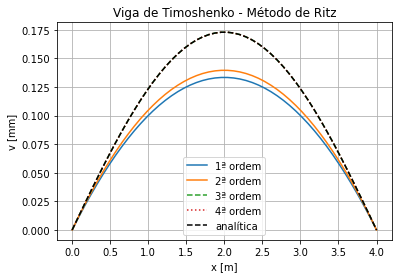

In [96]:
# Definir vetor x contendo pontos no domínio da viga
x_vals = np.linspace(0, L_val, 50)

# converter funções
v1_num = lambdify(x, v1s.subs(subs_vals), 'numpy')
v2_num = lambdify(x, v2s.subs(subs_vals), 'numpy')
v3_num = lambdify(x, v3s.subs(subs_vals), 'numpy')
v4_num = lambdify(x, v4s.subs(subs_vals), 'numpy')
v_exata_num = lambdify(x, h.subs(subs_vals), 'numpy')

# Plotagem da função v
plt.figure()
plt.plot(x_vals, 1000*v1_num(x_vals), label='1ª ordem')
plt.plot(x_vals, 1000*v2_num(x_vals), label='2ª ordem')
plt.plot(x_vals, 1000*v3_num(x_vals), linestyle='--', label='3ª ordem')
plt.plot(x_vals, 1000*v4_num(x_vals), linestyle=':', label='4ª ordem')
plt.plot(x_vals, 1000*v_exata_num(x_vals), 'k--', label='analítica')
plt.xlabel('x [m]')
plt.ylabel('v [mm]')
plt.title('Viga de Timoshenko - Método de Ritz')
plt.legend()
plt.grid()
plt.show()
print('')


### 🔹 Plotagem das soluções aproximadas
Também pode-se visualizar a rotação:

$$
\phi(x)
$$

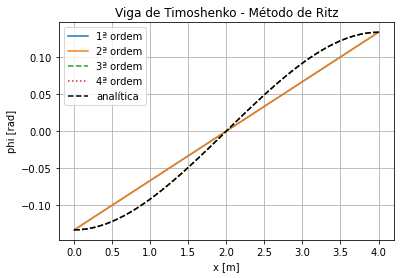

In [97]:
# Definir vetor x contendo pontos no domínio da viga
x_vals = np.linspace(0, L_val, 50)

# converter funções
phi1_num = lambdify(x, phi1s.subs(subs_vals), 'numpy')
phi2_num = lambdify(x, phi2s.subs(subs_vals), 'numpy')
phi3_num = lambdify(x, phi3s.subs(subs_vals), 'numpy')
phi4_num = lambdify(x, phi4s.subs(subs_vals), 'numpy')
phi_exata_num = lambdify(x, f.subs(subs_vals), 'numpy')

# Plotagem da função v
plt.figure()
plt.plot(x_vals, 1000*phi1_num(x_vals), label='1ª ordem')
plt.plot(x_vals, 1000*phi2_num(x_vals), label='2ª ordem')
plt.plot(x_vals, 1000*phi3_num(x_vals), linestyle='--', label='3ª ordem')
plt.plot(x_vals, 1000*phi4_num(x_vals), linestyle=':', label='4ª ordem')
plt.plot(x_vals, 1000*phi_exata_num(x_vals), 'k--', label='analítica')
plt.xlabel('x [m]')
plt.ylabel('phi [rad]')
plt.title('Viga de Timoshenko - Método de Ritz')
plt.legend()
plt.grid()
plt.show()
print('')

### 🔹 Tensões na viga de Timoshenko

Tensão normal (flexão):
$$
\sigma_x(x,y) = E\,y\,\frac{d\phi}{dx}
$$


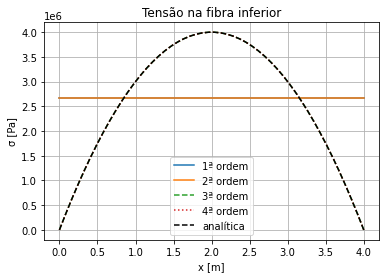

In [98]:
x_vals = np.linspace(0, L_val, 50)
y_inf = h_val/2

sigma1_num = lambdify(x, sigma1.subs(subs_vals).subs(y, y_inf), 'numpy')
sigma2_num = lambdify(x, sigma2.subs(subs_vals).subs(y, y_inf), 'numpy')
sigma3_num = lambdify(x, sigma3.subs(subs_vals).subs(y, y_inf), 'numpy')
sigma4_num = lambdify(x, sigma4.subs(subs_vals).subs(y, y_inf), 'numpy')
sigma_exata_num = lambdify(x, sigma.subs(subs_vals).subs(y, y_inf), 'numpy')

# Aqui trata-se o caso de retorno constante da funcao acima (caso nao dependa de x)
def make_vector_func(f):
    def f_vec(x_vals):
        y = f(x_vals)
        if np.isscalar(y) or np.shape(y) == ():
            return np.ones_like(x_vals) * y
        return y
    return f_vec
sigma1_num = make_vector_func(sigma1_num)
sigma2_num = make_vector_func(sigma2_num)
sigma3_num = make_vector_func(sigma3_num)
sigma4_num = make_vector_func(sigma4_num)
sigma_exata_num = make_vector_func(sigma_exata_num)

plt.figure()
plt.plot(x_vals, sigma1_num(x_vals), label='1ª ordem')
plt.plot(x_vals, sigma2_num(x_vals), label='2ª ordem')
plt.plot(x_vals, sigma3_num(x_vals), '--', label='3ª ordem')
plt.plot(x_vals, sigma4_num(x_vals), ':', label='4ª ordem')
plt.plot(x_vals, sigma_exata_num(x_vals), 'k--', label='analítica')

plt.xlabel('x [m]')
plt.ylabel('σ [Pa]')
plt.title('Tensão na fibra inferior')
plt.legend()
plt.grid()
plt.show()


### 🔹 Tensões na viga de Timoshenko

Tensão de cisalhamento:
$$
\tau_{xy}(x) = kG(\phi + v')
$$

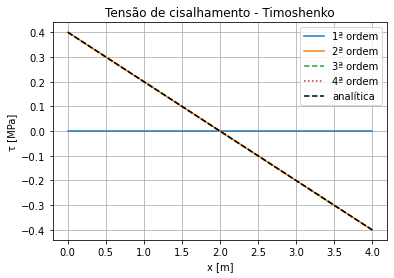

In [99]:
x_vals = np.linspace(0, L_val, 50)

# tensão de cisalhamento
tau1_num = lambdify(x, (k*G*(phi1s + v1s.diff(x))).subs(subs_vals), 'numpy')
tau2_num = lambdify(x, (k*G*(phi2s + v2s.diff(x))).subs(subs_vals), 'numpy')
tau3_num = lambdify(x, (k*G*(phi3s + v3s.diff(x))).subs(subs_vals), 'numpy')
tau4_num = lambdify(x, (k*G*(phi4s + v4s.diff(x))).subs(subs_vals), 'numpy')
tau_exata_num = lambdify(x, tau.subs(subs_vals), 'numpy')

# Aqui trata-se o caso de retorno constante da funcao acima (caso nao dependa de x)
def make_vector_func(f):
    def f_vec(x_vals):
        y = f(x_vals)
        if np.isscalar(y) or np.shape(y) == ():
            return np.ones_like(x_vals) * y
        return y
    return f_vec
tau1_num = make_vector_func(tau1_num)
tau2_num = make_vector_func(tau2_num)
tau3_num = make_vector_func(tau3_num)
tau4_num = make_vector_func(tau4_num)
tau_exata_num = make_vector_func(tau_exata_num)

# Plotagem da função v
plt.figure()
plt.plot(x_vals, tau1_num(x_vals)/1e6, label='1ª ordem')
plt.plot(x_vals, tau2_num(x_vals)/1e6, label='2ª ordem')
plt.plot(x_vals, tau3_num(x_vals)/1e6, linestyle='--', label='3ª ordem')
plt.plot(x_vals, tau4_num(x_vals)/1e6, linestyle=':', label='4ª ordem')
plt.plot(x_vals, tau_exata_num(x_vals)/1e6, 'k--', label='analítica')

plt.xlabel('x [m]')
plt.ylabel('τ [MPa]')
plt.title('Tensão de cisalhamento - Timoshenko')
plt.legend()
plt.grid()
plt.show()

## Funções resíduo

Resíduo do equilíbrio transversal:
$$
R_1(x) = \frac{d}{dx}\left[kGA(\phi_b + v_b')\right] + q(x)
$$

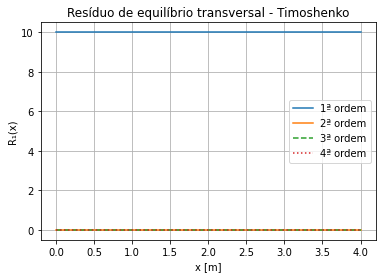

In [100]:
# garantir que não tem Derivative
R1_1_num = lambdify(x, R1_1.subs(subs_vals).doit(), 'numpy')
R1_2_num = lambdify(x, R1_2.subs(subs_vals).doit(), 'numpy')
R1_3_num = lambdify(x, R1_3.subs(subs_vals).doit(), 'numpy')
R1_4_num = lambdify(x, R1_4.subs(subs_vals).doit(), 'numpy')

x_vals = np.linspace(0, L_val, 50)

# Aqui trata-se o caso de retorno constante da funcao acima (caso nao dependa de x)
def make_vector_func(f):
    def f_vec(x_vals):
        y = f(x_vals)
        if np.isscalar(y) or np.shape(y) == ():
            return np.ones_like(x_vals) * y
        return y
    return f_vec
R1_1_num = make_vector_func(R1_1_num)
R1_2_num = make_vector_func(R1_2_num)
R1_3_num = make_vector_func(R1_3_num)
R1_4_num = make_vector_func(R1_4_num)

plt.figure()
plt.plot(x_vals, R1_1_num(x_vals), label='1ª ordem')
plt.plot(x_vals, R1_2_num(x_vals), label='2ª ordem')
plt.plot(x_vals, R1_3_num(x_vals), linestyle='--', label='3ª ordem')
plt.plot(x_vals, R1_4_num(x_vals), linestyle=':', label='4ª ordem')

plt.xlabel('x [m]')
plt.ylabel('R₁(x)')
plt.title('Resíduo de equilíbrio transversal - Timoshenko')
plt.legend()
plt.grid()

plt.show()

## Funções resíduo

Resíduo do  momento:
$$
R_2(x) = EI\,\phi_b'' - kGA(\phi_b + v_b')
$$

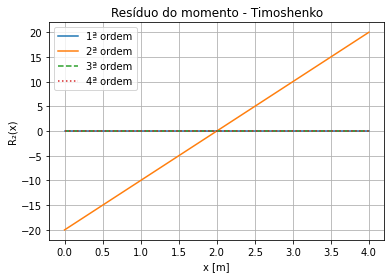

In [101]:
# garantir que não tem Derivative
R2_1_num = lambdify(x, R2_1.subs(subs_vals).doit(), 'numpy')
R2_2_num = lambdify(x, R2_2.subs(subs_vals).doit(), 'numpy')
R2_3_num = lambdify(x, R2_3.subs(subs_vals).doit(), 'numpy')
R2_4_num = lambdify(x, R2_4.subs(subs_vals).doit(), 'numpy')

x_vals = np.linspace(0, L_val, 50)

# Aqui trata-se o caso de retorno constante da funcao acima (caso nao dependa de x)
def make_vector_func(f):
    def f_vec(x_vals):
        y = f(x_vals)
        if np.isscalar(y) or np.shape(y) == ():
            return np.ones_like(x_vals) * y
        return y
    return f_vec
R2_1_num = make_vector_func(R2_1_num)
R2_2_num = make_vector_func(R2_2_num)
R2_3_num = make_vector_func(R2_3_num)
R2_4_num = make_vector_func(R2_4_num)

plt.figure()
plt.plot(x_vals, R2_1_num(x_vals), label='1ª ordem')
plt.plot(x_vals, R2_2_num(x_vals), label='2ª ordem')
plt.plot(x_vals, R2_3_num(x_vals), linestyle='--', label='3ª ordem')
plt.plot(x_vals, R2_4_num(x_vals), linestyle=':', label='4ª ordem')

plt.xlabel('x [m]')
plt.ylabel('R₂(x)')
plt.title('Resíduo do momento - Timoshenko')
plt.legend()
plt.grid()

plt.show()